# HOUSE PRICE PREDICTION PROJECT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\shibi\Downloads\Housing.csv.zip")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
df.shape

(21613, 21)

In [6]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [7]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [8]:
df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [9]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580306e+09,5.400886e+05,3.370795,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876570e+09,3.671268e+05,0.930105,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


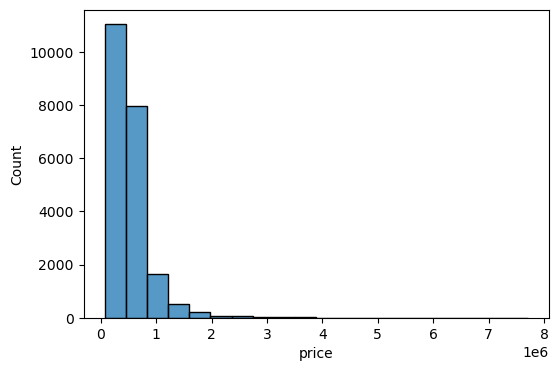

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["price"],bins=20)
plt.show()

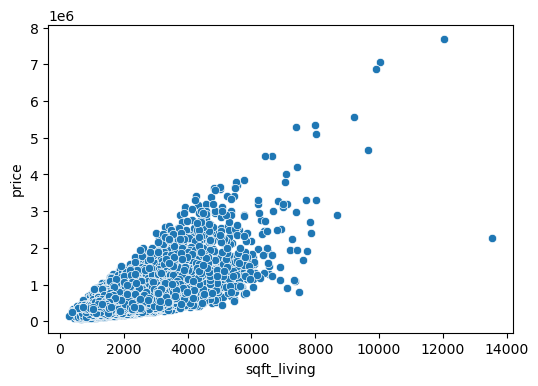

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sqft_living",y="price",data=df)
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X=df.drop(["price","date"],axis=1)
y=df["price"]

X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
predictions=model.predict(X_test)
print(predictions)

[ 464060.28862769  747620.84812363 1234931.51973793 ...  427134.11784813
  618498.07993529  446072.07217227]


In [15]:
from sklearn.metrics import r2_score
score=r2_score(y_test, predictions)
print(score)

0.7012450072964254


In [16]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test, predictions)
print(mae)

127474.39227866972


In [17]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,predictions)
print(mse)

45164797567.24759


In [18]:
import numpy as np
rmse=np.sqrt(mse)
print(rmse)

212520.1109712857


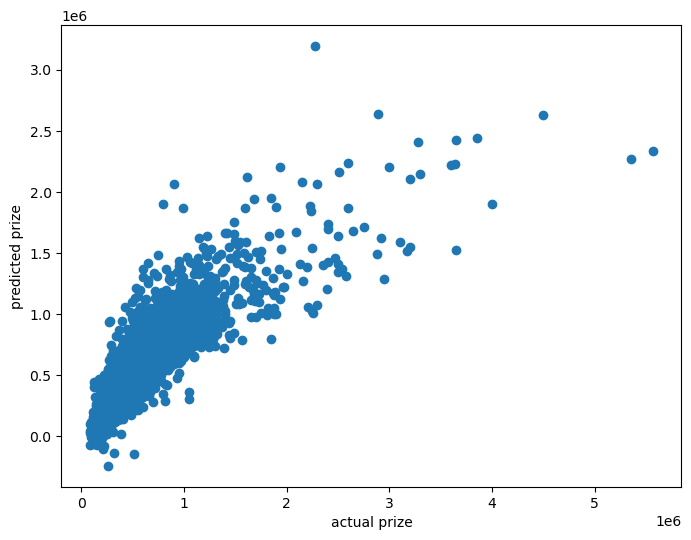

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test,predictions)
plt.xlabel("actual prize")
plt.ylabel("predicted prize")
plt.show()

In [21]:
coefficients=pd.DataFrame({
    "Features":X.columns,
    "Coefficients":model.coef_
})
print(coefficients)

         Features   Coefficients
0              id      -0.000001
1        bedrooms  -34307.425191
2       bathrooms   44588.724767
3     sqft_living     108.944453
4        sqft_lot       0.080567
5          floors    7022.950564
6      waterfront  561990.859478
7            view   53790.331498
8       condition   24383.273254
9           grade   94710.395379
10     sqft_above      69.944795
11  sqft_basement      38.999658
12       yr_built   -2682.056234
13   yr_renovated      20.243538
14        zipcode    -551.903917
15            lat  595411.545611
16           long -192586.543960
17  sqft_living15      21.136995
18     sqft_lot15      -0.339556


In [18]:
new_house=pd.DataFrame({
    "id":[1],
    "bedrooms":[2],
    "bathrooms":[3],
    "sqft_living":[2000],
    "sqft_lot":[5000],
    "floors":[2],
    "waterfront":[0],
    "view":[0],
    "condition":[3],
    "grade":[7],
    "sqft_above":[1800],
    "sqft_basement":[200],
    "yr_built":[2005],
    "yr_renovated":[0],
    "zipcode":[98001],
    "lat":[47.5],
    "long":[-122.2],
    "sqft_living15":[1900],
    "sqft_lot15":[5100]
})
model.predict(new_house)

array([446254.33500398])

# Conclusion

1. Linear Regression model was developed to predict house prices.
2. The dataset was cleaned and preprocessed.
3. Train-Test Split was used.
4. The model achieved a good R2 Score.
5. Mean Absolute Error,Mean Squared Error and RMSE were calculated.
6. Actual vs Predicted graph shows that predictions are close to actual values.
7. Feature coefficients indicate which variables influence house price the most.
8. The trained model can predict the price of a new house based on its features.